# Stress 04 — Extension Traps: When More Model Cures, and When It Just Adds Knobs

The series so far has stressed the **base** model, and the recurring prescription
was: *when the estimand is wrong, change the model* — a confounder needs a
control, a mediated channel needs its indirect path counted, a sibling product
needs joint modeling. This notebook stress-tests the prescription itself. The
framework's extension models (`NestedMMM`, `MultivariateMMM`, `CombinedMMM`) are
real cures for real structural biases — **and** every one of them ships with new
latent paths that the data may not identify. When that happens the extension
doesn't fail loudly; it returns a confident posterior whose shape came from the
prior, dressed in the language of structure.

Three acts, each on the same ladder — *setup → what the base model gets wrong →
the extension's fix → the extension's own failure mode → guardrail*:

1. **Mediation** (`NestedMMM`): the four-rung trap ladder — base model blind to a
   brand channel, the bad-control "fix" that textbooks warn about, the nested
   model that genuinely recovers the total effect, and then the trap nobody
   audits: *what if you nominate the wrong mediator?* We fit one and report what
   actually fires (spoiler: measure it).
2. **Multi-outcome** (`MultivariateMMM`): the under-identification trap,
   reproduced live — one directional cross-effect $\psi$ plus residual
   correlation $\rho$ gives 4 structural parameters against 3 data moments, so
   the $\psi/\rho$ **split is set by the prior**. Same data, two priors, two
   opposite stories.
3. **`CombinedMMM`**: the knob count compounds. The first edition of this act
   demonstrated the bill with a live tooling casualty — those framework bugs
   have since been fixed (this stress test is why); the *identification* bill
   it was pointing at has not, and we measure it on the repaired model.

Everything is graded against the **Aurora** world (`nbs/aurora.py`), whose
generative truth — per-channel ROAS, mediated share, the cannibalization
mechanism — is known exactly.

> Companions: `math_06_extensions.ipynb` (the extension equations, derived and
> verified), `stress_03` (confounding & controls — the act-1 ladder's
> prerequisites), `stress_00` (the doctrine: green diagnostics ≠ correct
> attribution).

In [1]:
import sys, pathlib, warnings, logging, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import arviz as az

warnings.filterwarnings("ignore")
for _n in ("pymc", "pymc.sampling", "numpyro", "jax", "arviz", "pytensor"):
    _lg = logging.getLogger(_n); _lg.setLevel(logging.ERROR); _lg.propagate = False
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # repo root (run from nbs/)

import contextlib, os
@contextlib.contextmanager
def quiet():
    "Hide the samplers' progress bars / chatter; our own prints stay visible."
    with open(os.devnull, "w") as _dn, contextlib.redirect_stdout(_dn), \
            contextlib.redirect_stderr(_dn):
        yield

from aurora import generate_aurora, CHANNELS, PALETTE, CHANNEL_COLORS

plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 4.2),
    "axes.grid": True, "grid.alpha": 0.18,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#cfc7bd", "axes.titleweight": "bold",
    "figure.facecolor": "white", "savefig.facecolor": "white", "font.size": 10,
})
INK, ACCENT, MUTED = PALETTE["ink"], PALETTE["accent"], PALETTE["muted"]
SKY, BERRY, LEAF, AMBER, CREMA = (PALETTE["sky"], PALETTE["berry"],
                                  PALETTE["leaf"], PALETTE["amber"], PALETTE["crema"])
TIMINGS = {}

aurora = generate_aurora()           # seeded; ~2 years weekly, truth known
X = aurora.media_matrix()
BRAND = ["TV", "Display"]            # the channels that work via awareness

print("TRUE total-effect ROAS:")
print(aurora.true_roas.round(2).to_string())
print("\nTRUE mediated share (fraction of effect flowing via awareness):")
print(aurora.true_mediated_share.round(3).to_string())

TRUE total-effect ROAS:
TV         2.14
Search     0.66
Social     0.49
Display    2.11

TRUE mediated share (fraction of effect flowing via awareness):
TV         0.988
Display    0.967
Search     0.000
Social     0.000


---
# Act 1 — Mediation: the four-rung trap ladder

Aurora's TV and Display sell almost nothing directly. They build **brand
awareness**, and awareness drives sales — their true mediated share is printed
above (≈1 for both), and their true total-effect ROAS is ≈2. The right estimand
for a budget decision is the **total** effect (direct + indirect); a model that
delivers anything else is answering a different question.

The ladder we will climb, fitting every rung live:

| rung | model | awareness enters as | the modeler's reasoning |
|---|---|---|---|
| **(a)** | base MMM | *(absent)* | "we don't have a use for survey data" |
| **(b)** | base MMM | a **control** | "awareness predicts sales — control for it!" |
| **(c)** | `NestedMMM` | a **mediator** | "awareness is *downstream* of media — model the path" |
| **(d)** | `NestedMMM` | the **wrong** mediator | "this index moves with sales, must be the funnel" |

Rungs (a) and (b) use the full causal toolkit from `stress_03` — the demand
proxy is included as a confounder control throughout, so whatever goes wrong
here is *not* the confounding we already know how to fix.

In [2]:
from mmm_framework import (BayesianMMM, ModelConfigBuilder, SeasonalityConfigBuilder,
                           TrendConfig, TrendType)
from mmm_framework.analysis import MMMAnalyzer
from mmm_framework.config import (ControlVariableConfig, DimensionType, KPIConfig,
                                  MediaChannelConfig, MFFConfig)
from mmm_framework.data_loader import PanelCoordinates, PanelDataset

def base_config():
    return (ModelConfigBuilder().bayesian_pymc().with_chains(2).with_draws(400)
            .with_tune(400)
            .with_seasonality_builder(SeasonalityConfigBuilder().with_yearly(order=2))
            .build())

def aurora_panel(extra: dict | None = None):
    "Aurora panel with Price + the CategoryDemand confounder control (+ extras)."
    extra = extra or {}
    controls = ["Price", "CategoryDemand"] + list(extra)
    ctrl = {"Price": aurora.price, "CategoryDemand": aurora.category_demand_index,
            **extra}
    coords = PanelCoordinates(periods=aurora.weeks, geographies=None, products=None,
                              channels=list(CHANNELS), controls=controls)
    cfg = MFFConfig(
        kpi=KPIConfig(name="Sales", dimensions=[DimensionType.PERIOD]),
        media_channels=[MediaChannelConfig(name=c, dimensions=[DimensionType.PERIOD])
                        for c in CHANNELS],
        controls=[ControlVariableConfig(name=c, dimensions=[DimensionType.PERIOD])
                  for c in controls])
    return PanelDataset(y=pd.Series(aurora.sales_total, name="Sales"),
                        X_media=aurora.spend.copy(), X_controls=pd.DataFrame(ctrl),
                        coords=coords, index=aurora.weeks, config=cfg)

def fit_base(label, extra=None):
    "Fit a base BayesianMMM (cores=1: macOS) and return (model, fit, ROAS series)."
    m = BayesianMMM(aurora_panel(extra), base_config(), TrendConfig(type=TrendType.LINEAR))
    t0 = time.perf_counter()
    with quiet():
        f = m.fit(draws=400, tune=400, chains=2, cores=1, random_seed=0)
    TIMINGS[label] = round(time.perf_counter() - t0, 1)
    with quiet():
        roas = MMMAnalyzer(m).compute_channel_roi(random_seed=0).set_index("Channel")["ROI"]
    print(f"{label}: fit {TIMINGS[label]}s   r-hat max {f.diagnostics['rhat_max']:.3f}, "
          f"divergences {f.diagnostics['divergences']}")
    return m, f, roas

m_a, f_a, roas_a = fit_base("(a) base, no awareness")
print("\nROAS (a) vs truth:")
print(pd.DataFrame({"true": aurora.true_roas, "(a) base": roas_a}).round(2).to_string())

Output()

There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Output()

Output()

Output()

Output()

Output()

(a) base, no awareness: fit 20.5s   r-hat max 1.013, divergences 1

ROAS (a) vs truth:
         true  (a) base
TV       2.14      0.34
Search   0.66      0.99
Social   0.49      0.89
Display  2.11      0.71


## Rung (a): the base model never sees the brand channels

Convergence is essentially clean, the confounder control is in — and read the
table: **TV and Display come back at a fraction of their true ROAS** while the
demand-chasing channels stay overstated (residual confounding through the noisy
proxy — `stress_03`'s territory). Where did the brand effect go?

Not "into the missing mediator variable" — the base model doesn't need the
awareness *series* to credit TV, because TV's total effect is still a function
of TV's spend. The mechanism is nastier: TV is an **always-on channel with heavy
carryover**, so its *saturated exposure* — the regressor the coefficient
actually multiplies — barely moves week to week. We can measure that:

In [3]:
# The regressor the coefficient actually multiplies is the channel's ADSTOCKED
# (then saturated) spend. Compute its CV (std/mean) across a whole grid of
# carryover values -- if it is flat for EVERY plausible alpha, no estimated
# transform can rescue identifiability (saturation only flattens it further).
def adstock_cv(ch, alpha, l_max=8):
    x = aurora.spend[ch].to_numpy(); xn = x / x.max()
    w = alpha ** np.arange(l_max); w = w / w.sum()
    pad = np.concatenate([np.zeros(l_max - 1), xn])
    ad = np.array([pad[t:t + l_max][::-1] @ w for t in range(len(xn))])
    return ad.std() / ad.mean()

grid = pd.DataFrame({ch: {f"alpha={a}": adstock_cv(ch, a) for a in (0.2, 0.5, 0.8)}
                     for ch in CHANNELS}).T
print("CV of each channel's adstocked exposure, across carryover values:")
print(grid.round(3).to_string())
print(f"\nTV's exposure CV is ≤ {grid.loc['TV'].max():.3f} for every carryover —")
print("effectively a constant regressor. A constant is exchangeable with the")
print("intercept/trend: the data cannot credit it, so the baseline keeps TV's effect.")

assert grid.loc["TV"].max() < 0.15, "TV exposure should be near-constant"
assert grid.loc["TV"].max() < grid.loc["Search"].min(), \
    "TV's exposure should vary far less than demand-chasing Search's"
assert roas_a["TV"] < 0.5 * aurora.true_roas["TV"], \
    "rung (a): base model should badly undervalue TV"
assert roas_a["Display"] < 0.5 * aurora.true_roas["Display"], \
    "rung (a): base model should badly undervalue Display"
print("\n✓ rung (a) measured: TV & Display recovered at <50% of true ROAS")

CV of each channel's adstocked exposure, across carryover values:
         alpha=0.2  alpha=0.5  alpha=0.8
TV           0.104      0.105      0.128
Search       0.314      0.302      0.300
Social       0.222      0.218      0.226
Display      0.129      0.137      0.164

TV's exposure CV is ≤ 0.128 for every carryover —
effectively a constant regressor. A constant is exchangeable with the
intercept/trend: the data cannot credit it, so the baseline keeps TV's effect.

✓ rung (a) measured: TV & Display recovered at <50% of true ROAS


> **Rung (a) takeaway.** The base model undervalues the brand channels not
> because the mediator variable is "missing" but because their effect rides a
> **slow, nearly-flat exposure** that the baseline absorbs. No amount of
> better priors fixes a constant regressor. This is an *information* problem —
> remember that; it decides what the extension must bring to actually help.

## Rung (b): the bad-control "fix"

The naive modeler now reaches for the awareness tracker: *"awareness predicts
sales; add it as a control."* `stress_03` (and every causal-inference text)
says this is the **bad-control trap**: awareness is *post-treatment* — TV's
effect flows *through* it, so conditioning on it blocks the indirect path and
the mediated channels get under-credited.

That is the textbook prediction. Let's measure what actually happens **here**.

In [4]:
m_b, f_b, roas_b = fit_base("(b) base + awareness control", {"Awareness": aurora.awareness})

ladder_ab = pd.DataFrame({"true": aurora.true_roas, "(a) no awareness": roas_a,
                          "(b) awareness as control": roas_b}).loc[list(CHANNELS)]
print("\nROAS ladder so far:")
print(ladder_ab.round(2).to_string())

# Where did the awareness control's credit go? Read the control coefficients.
cm_b = pd.Series(f_b.trace.posterior["beta_controls"].mean(dim=["chain", "draw"]).values,
                 index=m_b.control_names)
print("\nrung (b) control coefficients (standardized):")
print(cm_b.round(3).to_string())

for ch in BRAND:
    delta = roas_b[ch] - roas_a[ch]
    print(f"{ch}: bad-control damage = {delta:+.2f} ROAS vs rung (a)")

Output()

There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Output()

Output()

Output()

Output()

Output()

(b) base + awareness control: fit 17.4s   r-hat max 1.021, divergences 1

ROAS ladder so far:
         true  (a) no awareness  (b) awareness as control
TV       2.14              0.34                      0.32
Search   0.66              0.99                      0.80
Social   0.49              0.89                      0.70
Display  2.11              0.71                      0.62

rung (b) control coefficients (standardized):
Price            -0.177
CategoryDemand    0.407
Awareness         0.080
TV: bad-control damage = -0.03 ROAS vs rung (a)
Display: bad-control damage = -0.09 ROAS vs rung (a)


**The trap doesn't visibly bite — and that is itself the finding.** The brand
channels' ROAS barely moves from rung (a) to rung (b), and the awareness
control's own coefficient (printed above) is small. The textbook mechanism is
real, but it has nothing to steal: rung (a) had **already** surrendered TV's
effect to the baseline, because the exposure is flat. Two failures are masking
each other — the bad control looks harmless *only because the model never saw
the effect it would have blocked*.

This is worth a beat: if you A/B-test "with vs without awareness control" as a
robustness check, this world returns *"no difference — the control is safe"*.
A robustness check on a broken rung tells you nothing about the rung you should
be standing on.

In [5]:
# VERIFY rung (b): the bad control's measured damage is ~nil here -- because the
# base model never held the brand effect in the first place. Directional + seeded.
for ch in BRAND:
    assert abs(roas_b[ch] - roas_a[ch]) < 0.4, \
        f"{ch}: (a)->(b) ROAS shift should be small (nothing left to steal)"
assert abs(cm_b["Awareness"]) < 0.25, \
    "awareness control coefficient should be small (the baseline already won)"
assert roas_b["TV"] < 0.5 * aurora.true_roas["TV"], \
    "rung (b) is still blind to TV"
print("✓ rung (b) measured: awareness-as-control changes nothing detectable —")
print("  the textbook bad control is masked by rung (a)'s identification failure")

✓ rung (b) measured: awareness-as-control changes nothing detectable —
  the textbook bad control is masked by rung (a)'s identification failure


## Rung (c): `NestedMMM` — the extension that earns its keep

The mediation model changes two things at once, and it matters which one does
the work:

1. **The estimand.** The outcome equation routes TV and Display through a latent
   awareness series $m_t$: their total coefficient becomes
   $\beta_{c\to m}\gamma_m + \delta_c$ (product-of-coefficients indirect +
   direct), so the *total* effect is what gets reported. (Full derivation:
   `math_06_extensions.ipynb` §2.)
2. **The information.** The monthly awareness *survey* enters the likelihood and
   anchors $m_t$. This is **new data** the base model never used — and after
   rung (a) we know the base model's failure was an information problem, so this
   is exactly the currency that can fix it.

We map awareness to **both** brand channels (≥2 channels per mediator — required
for the per-channel `indirect_via_*` decomposition to mean anything).

In [6]:
from mmm_framework.mmm_extensions.models import NestedMMM
from mmm_framework.mmm_extensions.builders import (MediatorConfigBuilder,
                                                   NestedModelConfigBuilder)

def nested_config(med_name):
    return (NestedModelConfigBuilder()
            .add_mediator(MediatorConfigBuilder(med_name)
                          .partially_observed(observation_noise=0.1)  # monthly survey
                          .with_positive_media_effect(sigma=1.0)
                          .with_direct_effect(sigma=0.5)
                          .build())
            .map_channels_to_mediator(med_name, BRAND)   # >= 2 channels
            .build())

t0 = time.perf_counter()
nested = NestedMMM(X, aurora.sales_total, list(CHANNELS), nested_config("awareness"),
                   mediator_data={"awareness": aurora.awareness_survey},
                   index=aurora.weeks)
with quiet():
    nested.fit(draws=500, tune=500, chains=2, cores=1, random_seed=0)  # cores=1: macOS
TIMINGS["(c) NestedMMM"] = round(time.perf_counter() - t0, 1)
print(f"NestedMMM fitted in {TIMINGS['(c) NestedMMM']}s")

med = nested.get_mediation_effects().set_index("channel")
print(med.loc[BRAND, ["direct_effect", "total_indirect", "total_effect",
                      "proportion_mediated"]].round(3).to_string())

Output()

We recommend running at least 4 chains for robust computation of convergence diagnostics


NestedMMM fitted in 18.7s
         direct_effect  total_indirect  total_effect  proportion_mediated
channel                                                                  
TV               0.054         151.480       151.534                1.000
Display          0.107         186.281       186.388                0.999


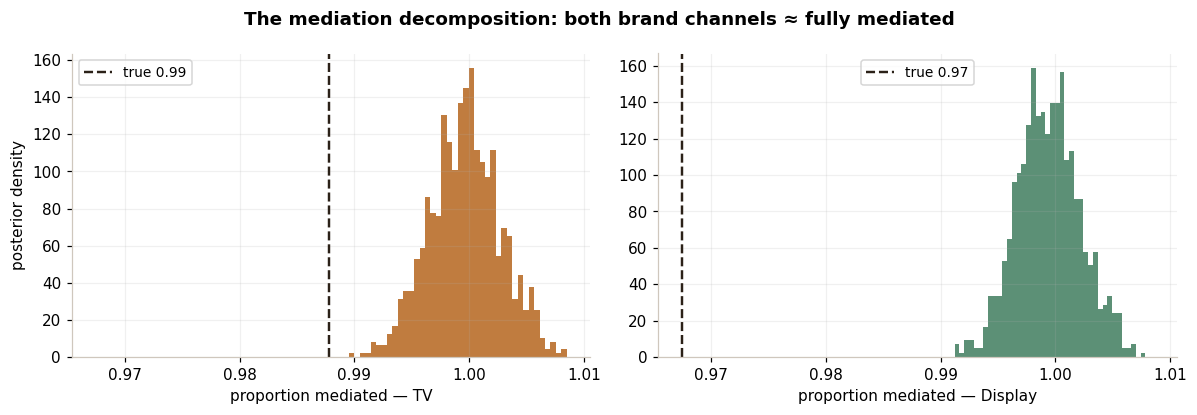

TV: proportion_mediated = 1.000   (true 0.988)
Display: proportion_mediated = 0.999   (true 0.967)
✓ proportion_mediated > 0.9 for both brand channels (matches the truth)


In [7]:
# The proportion-mediated POSTERIOR (not just the point estimate): per draw,
# prop = indirect / (indirect + direct).
post_n = nested.trace.posterior
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharex=True)
prop_draws = {}
for ax, ch in zip(axes, BRAND):
    ind = post_n[f"indirect_{ch}_via_awareness"].values.flatten()
    dlt = post_n[f"delta_direct_{ch}"].values.flatten()
    prop = ind / (ind + dlt)
    prop_draws[ch] = prop
    ax.hist(prop, bins=40, color=CHANNEL_COLORS[ch], alpha=0.85, density=True)
    ax.axvline(aurora.true_mediated_share[ch], color=INK, ls="--", lw=1.6,
               label=f"true {aurora.true_mediated_share[ch]:.2f}")
    ax.set_xlabel(f"proportion mediated — {ch}")
    ax.legend(fontsize=9)
axes[0].set_ylabel("posterior density")
fig.suptitle("The mediation decomposition: both brand channels ≈ fully mediated",
             fontweight="bold")
plt.tight_layout(); plt.show()

for ch in BRAND:
    pm_pt = float(med.loc[ch, "proportion_mediated"])
    print(f"{ch}: proportion_mediated = {pm_pt:.3f}   (true {aurora.true_mediated_share[ch]:.3f})")
    assert pm_pt > 0.9, f"{ch}: should be ≈ fully mediated"
print("✓ proportion_mediated > 0.9 for both brand channels (matches the truth)")

In [8]:
# Total-effect ROAS implied by the nested model, per posterior draw:
# coef_c = indirect + direct applies to the channel's saturated exposure u_c;
# ROAS_c = coef_c * sum(u_c) / sum(spend_c). u_c is rebuilt per draw from the
# channel's own (alpha, lambda) draws -- the same transform the model used.
def nested_roas_draws(model, ch, med_name="awareness"):
    p = model.trace.posterior
    i = list(CHANNELS).index(ch)
    x = X[:, i]; xn = x / (x.max() + 1e-8)
    alpha = p[f"alpha_{ch}"].values.flatten()
    lam = p[f"lambda_{ch}"].values.flatten()
    coef = (p[f"indirect_{ch}_via_{med_name}"].values.flatten()
            + p[f"delta_direct_{ch}"].values.flatten())
    pad = np.concatenate([np.zeros(7), xn])
    roas = np.empty(len(alpha))
    for d in range(len(alpha)):
        w = alpha[d] ** np.arange(8); w = w / w.sum()
        ad = np.array([pad[t:t + 8][::-1] @ w for t in range(len(xn))])
        u = 1 - np.exp(-lam[d] * ad)
        roas[d] = coef[d] * u.sum() / x.sum()
    return roas

roas_c, roas_c_hdi = {}, {}
for ch in BRAND:
    d = nested_roas_draws(nested, ch)
    roas_c[ch] = d.mean()
    roas_c_hdi[ch] = (np.percentile(d, 3), np.percentile(d, 97))
    print(f"NestedMMM total-effect ROAS {ch}: {d.mean():.2f} "
          f"[{roas_c_hdi[ch][0]:.2f}, {roas_c_hdi[ch][1]:.2f}]   "
          f"(true {aurora.true_roas[ch]:.2f})")

NestedMMM total-effect ROAS TV: 2.29 [1.97, 2.62]   (true 2.14)


NestedMMM total-effect ROAS Display: 5.47 [4.76, 6.15]   (true 2.11)


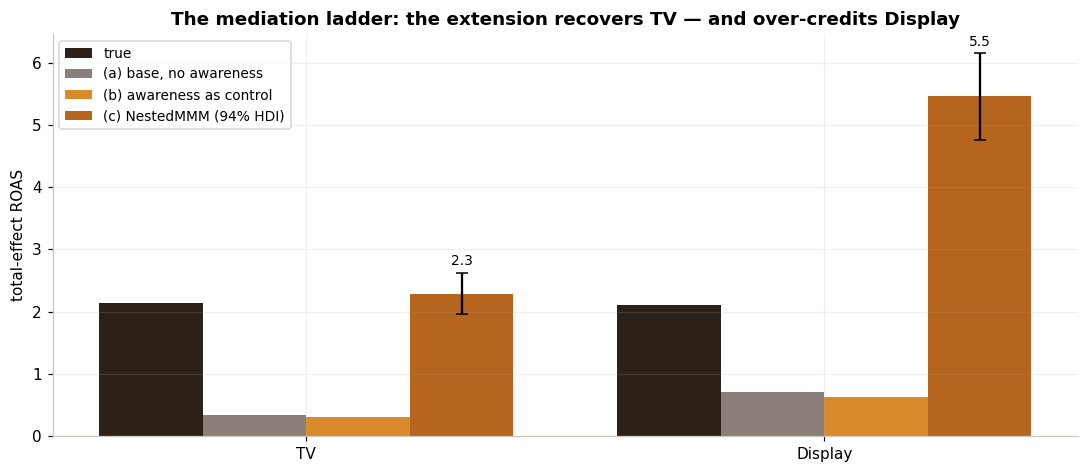

In [9]:
# THE LADDER, in one picture: truth vs rungs (a), (b), (c) for the brand channels.
fig, ax = plt.subplots(figsize=(10, 4.4))
xpos = np.arange(len(BRAND)); w = 0.2
ax.bar(xpos - 1.5 * w, [aurora.true_roas[c] for c in BRAND], w, color=INK, label="true")
ax.bar(xpos - 0.5 * w, [roas_a[c] for c in BRAND], w, color=MUTED,
       label="(a) base, no awareness")
ax.bar(xpos + 0.5 * w, [roas_b[c] for c in BRAND], w, color=AMBER,
       label="(b) awareness as control")
err = np.array([[roas_c[c] - roas_c_hdi[c][0] for c in BRAND],
                [roas_c_hdi[c][1] - roas_c[c] for c in BRAND]])
bars = ax.bar(xpos + 1.5 * w, [roas_c[c] for c in BRAND], w, color=ACCENT,
              yerr=err, capsize=4, label="(c) NestedMMM (94% HDI)")
ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)
ax.set_xticks(xpos); ax.set_xticklabels(BRAND)
ax.set_ylabel("total-effect ROAS")
ax.set_title("The mediation ladder: the extension recovers TV — and over-credits Display")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**Read both halves of that chart.** The nested model hauls TV from a
baseline-absorbed shadow back to its true ROAS — the survey anchors the
awareness path, the estimand becomes the total effect, and the interval covers
the truth. That is the cure, and it is genuine.

Now look at Display: the same fit puts it at **roughly 2.5× its true ROAS, with
an interval that excludes the truth**. The extension that fixed TV is
*confidently wrong* about its sibling. Why?

In [10]:
# VERIFY the two halves of rung (c). Directional + seeded.
tv_true, dp_true = aurora.true_roas["TV"], aurora.true_roas["Display"]
assert abs(roas_c["TV"] - tv_true) / tv_true < 0.35, \
    "nested TV ROAS should land within ±35% of truth"
assert roas_c_hdi["TV"][0] < tv_true < roas_c_hdi["TV"][1], \
    "nested TV interval should cover the truth"
assert abs(roas_c["TV"] - tv_true) < abs(roas_a["TV"] - tv_true), \
    "nested must beat rung (a) on TV"
assert roas_c["Display"] > 1.3 * dp_true, \
    "nested should OVER-credit Display (the split trap)"
assert roas_c_hdi["Display"][0] > dp_true, \
    "nested Display interval should EXCLUDE the truth (confidently wrong)"
print("✓ TV: recovered (interval covers truth, point within ±35%)")
print("✓ Display: over-credited >1.3x with an interval excluding the truth")

✓ TV: recovered (interval covers truth, point within ±35%)
✓ Display: over-credited >1.3x with an interval excluding the truth


In [11]:
# The mechanism: the two channels share ONE mediator, and the data only pins
# their JOINT path. Compare the two channel->mediator edges to the truth.
b_tv = float(post_n["beta_TV_to_awareness"].mean())
b_dp = float(post_n["beta_Display_to_awareness"].mean())
g = float(post_n["gamma_awareness"].mean())
print(f"beta_TV->awareness      = {b_tv:6.1f}   (true 45)")
print(f"beta_Display->awareness = {b_dp:6.1f}   (true 22)")
print(f"gamma_awareness         = {g:6.1f}   (true  5.4)")
print(f"\nproducts (the identified-ish quantity):")
print(f"  TV:      beta*gamma = {b_tv*g:6.1f}")
print(f"  Display: beta*gamma = {b_dp*g:6.1f}")
print(f"true contribution ratio TV:Display = "
      f"{aurora.true_contribution['TV']/aurora.true_contribution['Display']:.2f} : 1")

# TV's edge is unidentified for the SAME reason rung (a) failed: its exposure is
# near-constant (CV printed in rung (a)), so beta_TV is exchangeable with the
# mediator's intercept. The prior splits the brand credit ~evenly; Display's
# smaller spend then inflates its ROAS.
assert b_tv < 0.6 * 45, "beta_TV should be far below its true 45 (unidentified edge)"
assert g > 1.5 * 5.4, "gamma should over-scale to compensate"
print("\n✓ the structural parameters are NOT recovered — only (some) products are.")
print("  The unidentifiability of rung (a) did not vanish; it MOVED into the")
print("  mediator equation, where nobody was looking at it.")

beta_TV->awareness      =   12.2   (true 45)
beta_Display->awareness =   15.0   (true 22)
gamma_awareness         =   12.4   (true  5.4)

products (the identified-ish quantity):
  TV:      beta*gamma =  151.5
  Display: beta*gamma =  186.3
true contribution ratio TV:Display = 2.15 : 1

✓ the structural parameters are NOT recovered — only (some) products are.
  The unidentifiability of rung (a) did not vanish; it MOVED into the
  mediator equation, where nobody was looking at it.


> **Rung (c) takeaway.** The extension genuinely fixed the estimand *for the
> question the new data could answer*: "what does the **awareness path as a
> whole** contribute?" It silently did **not** fix the per-channel split through
> that shared mediator — TV's edge into awareness is as flat-exposure-blind as
> rung (a) was, so the split is prior symmetry, and the smaller-spend channel's
> ROAS inflates. **Read per-mediator totals with confidence; treat the
> per-channel split through a shared mediator as a labeled assumption** unless
> the exposures genuinely decorrelate — or a per-channel experiment pins one
> edge. And never quote $\beta$, $\gamma$ point estimates as mechanism: only
> their products faced the data.

## Rung (d): the wrong mediator — what fires? (measure, don't assume)

Mediation analysis has a dirty secret: the model cannot tell a mediator from
anything else that co-moves with sales. Suppose the modeler, impressed by rung
(c), nominates the **category demand index** as the funnel metric — *"it tracks
our sales and our spend, it must be mid-funnel"*. In Aurora's truth that
variable is a noisy proxy of the **demand confounder**: it *causes* spend (the
team chases it) and sales; media does not cause *it*.

Same `NestedMMM`, same mapping (TV, Display → "mediator"), wrong arrow. If the
extension has any self-awareness, something should fire: a divergence storm, a
weird `proportion_mediated`, an interval blowout. Fit it and check everything.

In [12]:
t0 = time.perf_counter()
wrong = NestedMMM(X, aurora.sales_total, list(CHANNELS), nested_config("demand_proxy"),
                  mediator_data={"demand_proxy": aurora.category_demand_index},
                  index=aurora.weeks)
with quiet():
    wrong.fit(draws=500, tune=500, chains=2, cores=1, random_seed=0)
TIMINGS["(d) NestedMMM wrong mediator"] = round(time.perf_counter() - t0, 1)

medw = wrong.get_mediation_effects().set_index("channel")
post_w = wrong.trace.posterior
roas_d = {ch: nested_roas_draws(wrong, ch, "demand_proxy").mean() for ch in BRAND}

scorecard = pd.DataFrame({
    "(c) RIGHT mediator": {
        "proportion_mediated TV": float(med.loc["TV", "proportion_mediated"]),
        "proportion_mediated Display": float(med.loc["Display", "proportion_mediated"]),
        "ROAS TV (true 2.14)": roas_c["TV"],
        "ROAS Display (true 2.11)": roas_c["Display"],
        "max r-hat (key params)": float(az.rhat(post_n[["gamma_awareness",
            "delta_direct_TV", "delta_direct_Display"]]).to_array().max()),
        "divergences": int(nested.trace.sample_stats["diverging"].sum()),
    },
    "(d) WRONG mediator (confounder!)": {
        "proportion_mediated TV": float(medw.loc["TV", "proportion_mediated"]),
        "proportion_mediated Display": float(medw.loc["Display", "proportion_mediated"]),
        "ROAS TV (true 2.14)": roas_d["TV"],
        "ROAS Display (true 2.11)": roas_d["Display"],
        "max r-hat (key params)": float(az.rhat(post_w[["gamma_demand_proxy",
            "delta_direct_TV", "delta_direct_Display"]]).to_array().max()),
        "divergences": int(wrong.trace.sample_stats["diverging"].sum()),
    },
}).round(3)
display(scorecard)

Output()

We recommend running at least 4 chains for robust computation of convergence diagnostics


,(c) RIGHT mediator,(d) WRONG mediator (confounder!)
proportion_mediated TV,1.000,1.000
proportion_mediated Display,0.999,0.999
ROAS TV (true 2.14),2.291,2.357
ROAS Display (true 2.11),5.466,5.059
max r-hat (key params),1.010,1.004
divergences,0.000,0.000


**Nothing fires.** Walk the scorecard:

- `proportion_mediated` is ≈1.0 in **both** columns — the wrong-mediator fit is
  *exactly as confident* in its mediation story as the right one. The
  decomposition is conditional on the arrow you drew; it cannot audit the arrow.
- r-hat clean, divergences ≈0 in both. The sampler is perfectly happy to route
  the brand channels through a confounder.
- Even the headline ROAS comes back plausible — the proxy co-moves with sales,
  so the product $\beta\gamma$ lands in the same range. A modeler comparing
  rung (d) to rung (a) would see "TV finally makes sense!" and *ship it*.

The story it tells, though, is causally upside down: it claims TV *builds*
category demand (it does not — demand drives TV's budget), and any budget
simulation that leans on that path (e.g. "cut TV, demand falls") inherits the
inverted arrow. Is there *any* tell? One — and only if you run the learning
diagnostic, and only as a whimper:

(c) right                           (d) wrong          \
                    contraction overlap shift_z verdict contraction overlap   
parameter                                                                     
beta_TV_to_<m>            -1.28     0.0   19.72    weak       -1.44     0.0   
beta_Display_to_<m>       -1.15     0.0   23.53    weak       -1.26     0.0   
gamma_<m>                  1.00     0.0   12.43  strong        1.00     0.0   

                                     
                    shift_z verdict  
parameter                            
beta_TV_to_<m>        30.40    weak  
beta_Display_to_<m>   32.93    weak  
gamma_<m>              7.70  strong

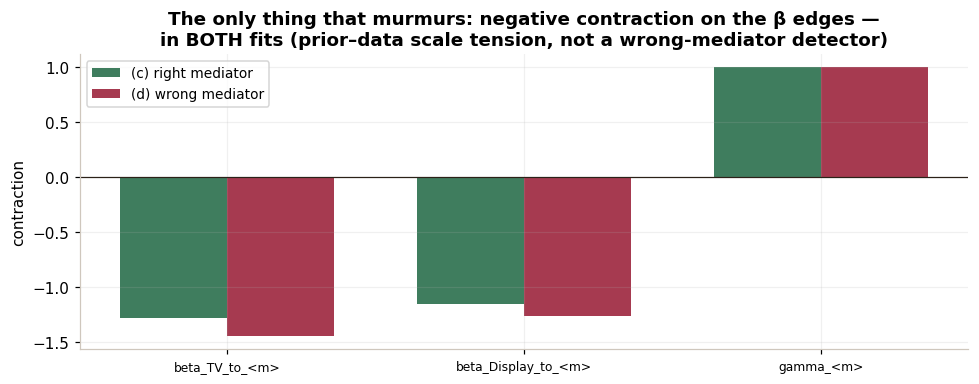

✓ measured: the prior–data-conflict flag (contraction < 0) fires on the
  channel→mediator edges in BOTH fits — it flags scale tension, and is NOT
  a wrong-mediator detector. No model output separates rungs (c) and (d).


In [13]:
# Prior->posterior learning on the channel->mediator edges, right vs wrong fit.
with quiet():
    lrn_r = nested.compute_parameter_learning(prior_samples=1000, random_seed=0)
    lrn_w = wrong.compute_parameter_learning(prior_samples=1000, random_seed=0)

def edge_rows(lrn, med_name):
    "The channel->mediator edges + the mediator->outcome edge."
    keep = [f"beta_{ch}_to_{med_name}" for ch in BRAND] + [f"gamma_{med_name}"]
    sel = lrn[lrn.parameter.isin(keep)].copy()
    sel["parameter"] = sel["parameter"].str.replace(f"_{med_name}", "_<m>", regex=False)
    return sel.set_index("parameter")[["contraction", "overlap", "shift_z", "verdict"]]

# (Multi-channel mediators once also carried a dead aggregate
# `beta_media_to_<m>` RV — never used by the graph, but polluting posteriors
# and this very table. The framework no longer creates it; verify.)
assert not lrn_r.parameter.str.contains("beta_media_to").any(), \
    "the dead aggregate media->mediator RV should be gone from the model"

cmp_lrn = pd.concat({"(c) right": edge_rows(lrn_r, "awareness"),
                     "(d) wrong": edge_rows(lrn_w, "demand_proxy")}, axis=1).round(2)
display(cmp_lrn)

fig, ax = plt.subplots(figsize=(9, 3.6))
params = cmp_lrn.index.tolist()
xb = np.arange(len(params)); w = 0.36
ax.bar(xb - w/2, cmp_lrn[("(c) right", "contraction")], w, color=LEAF, label="(c) right mediator")
ax.bar(xb + w/2, cmp_lrn[("(d) wrong", "contraction")], w, color=BERRY, label="(d) wrong mediator")
ax.axhline(0, color=INK, lw=0.8)
ax.set_xticks(xb); ax.set_xticklabels(params, fontsize=8)
ax.set_ylabel("contraction")
ax.set_title("The only thing that murmurs: negative contraction on the β edges —\n"
             "in BOTH fits (prior–data scale tension, not a wrong-mediator detector)")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

b_rows_r = cmp_lrn[("(c) right", "contraction")].filter(like="beta")
b_rows_w = cmp_lrn[("(d) wrong", "contraction")].filter(like="beta")
assert (b_rows_w < 0).all(), "wrong fit: beta edges should show negative contraction"
assert (b_rows_r < 0).all(), \
    "right fit shows the SAME negative contraction — it does NOT discriminate"
assert float(medw.loc["TV", "proportion_mediated"]) > 0.9, \
    "wrong mediator: proportion_mediated should be just as confident"
print("✓ measured: the prior–data-conflict flag (contraction < 0) fires on the")
print("  channel→mediator edges in BOTH fits — it flags scale tension, and is NOT")
print("  a wrong-mediator detector. No model output separates rungs (c) and (d).")

> **Rung (d) takeaway — the honest one.** We went looking for the alarm and
> there is none: `proportion_mediated` ≈ 1 either way, sampling is clean either
> way, the ROAS is plausible either way, and the one diagnostic that reacts
> (negative contraction on the $\beta$ edges) reacts *identically* in the
> correct fit. **Mediator validity is a causal assumption, full stop.** It must
> be earned outside the model — time order, an experiment that moves the
> mediator, a DAG argument that survives review (`stress_03` §DAG; the EDA tell
> is *media predicts the candidate*, not *the candidate predicts sales*). The
> extension will faithfully decompose whatever arrow you hand it, including a
> backwards one.

---
# Act 2 — Multi-outcome: the split the data cannot make

Aurora sells two products. In truth, summer **Cold Brew pressure eats
Original's sales** (a real substitution term in the DGP), *and* both products
ride one demand wave. `MultivariateMMM` models both products jointly and offers
two couplings:

$$
\mu_{\text{orig},t} = a + \textstyle\sum_c \beta_c u_{c,t}
  + \psi\, y_{\text{cb},t},
\qquad
\mathbf{y}_t \sim \mathrm{MvNormal}(\boldsymbol\mu_t, \Sigma)
$$

a directional **cross-effect $\psi$** on the *observed* sibling outcome (mean
structure), and the **residual correlation $\rho$** inside $\Sigma$ (noise
structure, LKJ prior).

**Count what the data offers.** For the residual co-movement of two outcomes,
the likelihood supplies three moments: $\mathrm{Var}(y_1)$, $\mathrm{Var}(y_2)$,
$\mathrm{Cov}(y_1,y_2)$. The structure asks for four parameters: $\sigma_1,
\sigma_2, \rho$, **and** $\psi$. With $\psi$ multiplying the *observed* $y_2$,
$\psi$ and $\rho$ produce observationally equivalent co-movement — the data pins
their **total**, and the **split is whatever the prior says**. (The framework
itself warns about exactly this — see the identification caveat in
`mmm_extensions.builders.cross_effect`'s docstring.)

That predicts something testable and damning: *refit the same model on the same
data with a different prior on $\psi$, and the "story" should flip.* Let's do
exactly that.

In [14]:
from mmm_framework.mmm_extensions.models import MultivariateMMM
from mmm_framework.mmm_extensions.builders import (
    MultivariateModelConfigBuilder, OutcomeConfigBuilder,
    cannibalization_effect, cross_effect)

_, outcomes = aurora.extension_inputs()

def fit_mv(ce, label):
    cfg = (MultivariateModelConfigBuilder()
           .add_outcome(OutcomeConfigBuilder("sales_original", column="sales_original")
                        .with_positive_media_effects(sigma=0.5).build())
           .add_outcome(OutcomeConfigBuilder("sales_coldbrew", column="sales_coldbrew")
                        .with_positive_media_effects(sigma=0.5).build())
           .add_cross_effect(ce)        # Cold Brew -> Original
           .build())
    m = MultivariateMMM(X, outcomes, list(CHANNELS), cfg, index=aurora.weeks)
    t0 = time.perf_counter()
    with quiet():
        m.fit(draws=500, tune=500, chains=2, cores=1, random_seed=0)  # cores=1: macOS
    TIMINGS[label] = round(time.perf_counter() - t0, 1)
    spec = m._cross_effect_specs[0]   # orientation-safe psi slice
    psi = m._trace.posterior["psi_matrix"][:, :, spec.source_idx, spec.target_idx] \
        .values.flatten()
    rho = float(m.get_correlation_matrix().loc["sales_original", "sales_coldbrew"])
    print(f"{label}: fit {TIMINGS[label]}s  "
          f"psi mean {psi.mean():+.4f}  P(psi<0) {(psi < 0).mean():.3f}  rho {rho:+.3f}")
    return m, psi, rho

# Fit 1: the "cannibalization" arrow -- psi = -HalfNormal, structurally <= 0.
mv_can, psi_can, rho_can = fit_mv(
    cannibalization_effect(source="sales_coldbrew", target="sales_original"),
    "MV cannibalization prior")

# Fit 2: the signless arrow -- psi ~ Normal(0, 0.5), the data picks the sign.
mv_unc, psi_unc, rho_unc = fit_mv(
    cross_effect(source="sales_coldbrew", target="sales_original", prior_sigma=0.5),
    "MV unconstrained prior")

Output()

We recommend running at least 4 chains for robust computation of convergence diagnostics


MV cannibalization prior: fit 18.0s  psi mean -0.0003  P(psi<0) 1.000  rho +0.407


Output()

We recommend running at least 4 chains for robust computation of convergence diagnostics


MV unconstrained prior: fit 14.4s  psi mean +1.8018  P(psi<0) 0.000  rho -0.141


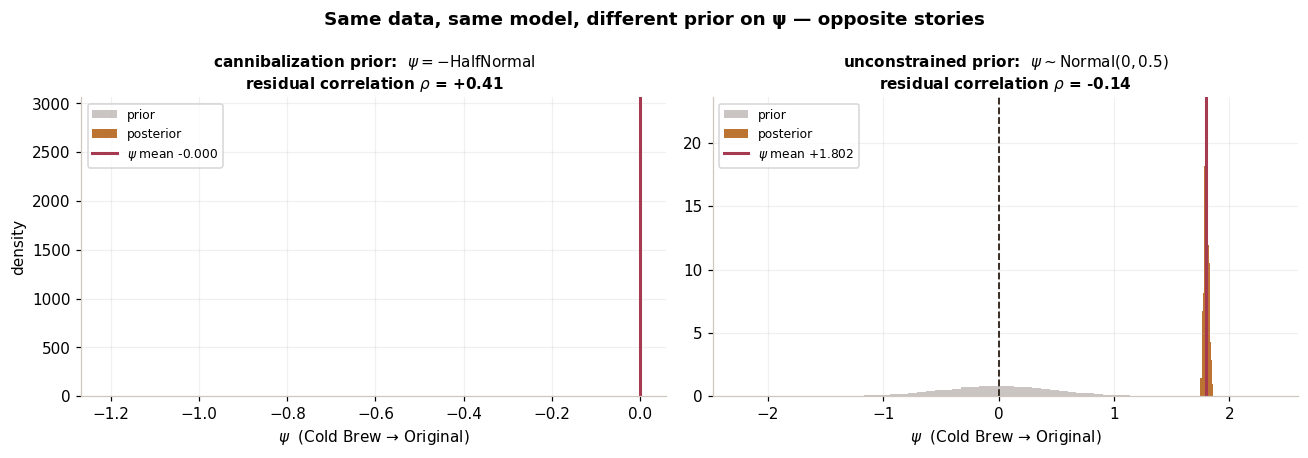

,psi (mean),P(psi<0),psi effect as % of Original's weekly sales,residual corr rho
cannibalization prior,-0.000,1.0,0.013,0.407
unconstrained prior,1.802,0.0,78.074,-0.141


In [15]:
# THE FLIP, side by side: same data, two priors, two opposite stories.
rng = np.random.default_rng(0)
prior_can = -np.abs(rng.normal(0, 0.3, 20000))     # cannibalization prior on psi
prior_unc = rng.normal(0, 0.5, 20000)              # unconstrained prior on psi

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, psi, prior, rho, ttl in [
        (axes[0], psi_can, prior_can, rho_can,
         "cannibalization prior:  $\\psi = -\\mathrm{HalfNormal}$"),
        (axes[1], psi_unc, prior_unc, rho_unc,
         "unconstrained prior:  $\\psi \\sim \\mathrm{Normal}(0, 0.5)$")]:
    ax.hist(prior, bins=60, density=True, color=MUTED, alpha=0.45, label="prior")
    ax.hist(psi, bins=60, density=True, color=ACCENT, alpha=0.9, label="posterior")
    ax.axvline(0, color=INK, lw=1.2, ls="--")
    ax.axvline(psi.mean(), color=BERRY, lw=2,
               label=f"$\\psi$ mean {psi.mean():+.3f}")
    ax.set_title(ttl + f"\nresidual correlation $\\rho$ = {rho:+.2f}", fontsize=10)
    ax.set_xlabel("$\\psi$  (Cold Brew → Original)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("density")
fig.suptitle("Same data, same model, different prior on ψ — opposite stories",
             fontweight="bold")
plt.tight_layout(); plt.show()

# Translate each psi into business units, and show where the co-movement "went".
flip = pd.DataFrame({
    "psi (mean)": [psi_can.mean(), psi_unc.mean()],
    "P(psi<0)": [(psi_can < 0).mean(), (psi_unc < 0).mean()],
    "psi effect as % of Original's weekly sales": [
        100 * np.abs(psi_can.mean() * aurora.sales_coldbrew).mean() / aurora.sales_original.mean(),
        100 * np.abs(psi_unc.mean() * aurora.sales_coldbrew).mean() / aurora.sales_original.mean()],
    "residual corr rho": [rho_can, rho_unc],
}, index=["cannibalization prior", "unconstrained prior"]).round(3)
display(flip)

**Read the flip.** Under the sign-constrained prior, $\psi$ collapses onto its
boundary at zero — "no direct cannibalization" — and the products' co-movement
lands in a solidly **positive** residual correlation (the shared demand wave).
Under the signless prior on the *same data*, $\psi$ swings to a large
**positive** value — mechanically reading "Cold Brew *lifts* Original" — worth
the better part of Original's weekly sales, while the residual correlation
flips sign to mop up the difference. Two fits, one likelihood, two
contradictory mechanisms; the only thing that changed is the prior. The
directional/symmetric **split is not in the data**, exactly as the moment count
said. (And recall the DGP *does* contain true substitution — neither fit found
it: the cross-effect-on-observed-outcome parameterization can't, no matter the
prior.)

And the trap inside the trap: under the cannibalization prior,
$\mathbb{P}(\psi<0)\approx 1$ — which sounds like overwhelming evidence and is
in fact **a property of the prior** (every HalfNormal draw is already negative).
A slide saying "we are >99.9% sure Cold Brew cannibalizes Original" would
survive most reviews and contain no data-derived content about the sign at all.

In [16]:
# VERIFY the flip. Directional + seeded.
assert (psi_can < 0).mean() > 0.999, "sign-constrained: P(psi<0)~1 by construction"
assert abs(psi_can.mean()) < 0.01, "cannibalization prior: psi pinned ~0 (boundary)"
assert rho_can > 0.3, "cannibalization prior: co-movement carried by rho > 0.3"
assert psi_unc.mean() > 1.0, "unconstrained prior: psi flips to strongly POSITIVE"
assert (psi_unc > 0).mean() > 0.99, "unconstrained: P(psi>0) ~ 1 on the same data"
assert rho_unc < 0.1, "unconstrained prior: rho gives up the co-movement"
share_unc = np.abs(psi_unc.mean() * aurora.sales_coldbrew).mean() / aurora.sales_original.mean()
assert share_unc > 0.4, "unconstrained psi is a HUGE effect in business units"
print("✓ psi: ~0 under one prior, large-positive under the other — same data")
print("✓ rho: +0.3-0.5 under one prior, ~0/negative under the other")
print("✓ P(psi<0): 1.000 vs ~0.000 — the 'sign evidence' was the prior's signature")

✓ psi: ~0 under one prior, large-positive under the other — same data
✓ rho: +0.3-0.5 under one prior, ~0/negative under the other
✓ P(psi<0): 1.000 vs ~0.000 — the 'sign evidence' was the prior's signature


## The guardrail — and how to read it without fooling yourself

`compute_parameter_learning` (prior→posterior **contraction**/overlap,
`diagnostics/learning.py`) is the framework's anti-vacuity check: did the data
move/narrow this parameter beyond its prior? Run it on $\psi$ in both fits —
and then read it with the discipline it requires.

In [17]:
with quiet():
    lrn_can = mv_can.compute_parameter_learning(prior_samples=2000, random_seed=0)
    lrn_unc = mv_unc.compute_parameter_learning(prior_samples=2000, random_seed=0)

psi_row_can = lrn_can[lrn_can.parameter.str.contains("psi")].iloc[0]
psi_row_unc = lrn_unc[lrn_unc.parameter.str.contains("psi")].iloc[0]
tbl = pd.DataFrame([psi_row_can, psi_row_unc],
                   index=["psi_1_0_raw (cannibal. fit)", "psi_1_0 (uncon. fit)"])
display(tbl[["prior_sd", "post_sd", "contraction", "overlap", "shift_z", "verdict"]].round(4))

print(f"contraction: {psi_row_can.contraction:.3f} (cannibal.) vs "
      f"{psi_row_unc.contraction:.3f} (unconstrained) — BOTH ≈ 1.")
print("The data 'confidently pinned' psi in both fits... to two different values")
print("with two different mechanisms. Contraction is COMPUTED WITHIN A MODEL:")
print("it certifies the data informed *that* parameterization, not that the")
print("parameterization asks an identifiable question.")

assert psi_row_can.contraction > 0.95 and psi_row_unc.contraction > 0.95, \
    "psi contracts hard under BOTH priors"
assert psi_row_can.overlap < 0.3 and psi_row_unc.overlap < 0.3
print("\n✓ contraction ≈ 1 and overlap ≈ 0 for psi under BOTH priors")

,prior_sd,post_sd,contraction,overlap,shift_z,verdict
psi_1_0_raw (cannibal. fit),0.1764,0.0003,1.0000,0.0525,-1.3380,strong
psi_1_0 (uncon. fit),0.4915,0.0197,0.9984,0.0000,3.6611,strong


contraction: 1.000 (cannibal.) vs 0.998 (unconstrained) — BOTH ≈ 1.
The data 'confidently pinned' psi in both fits... to two different values
with two different mechanisms. Contraction is COMPUTED WITHIN A MODEL:
it certifies the data informed *that* parameterization, not that the
parameterization asks an identifiable question.

✓ contraction ≈ 1 and overlap ≈ 0 for psi under BOTH priors


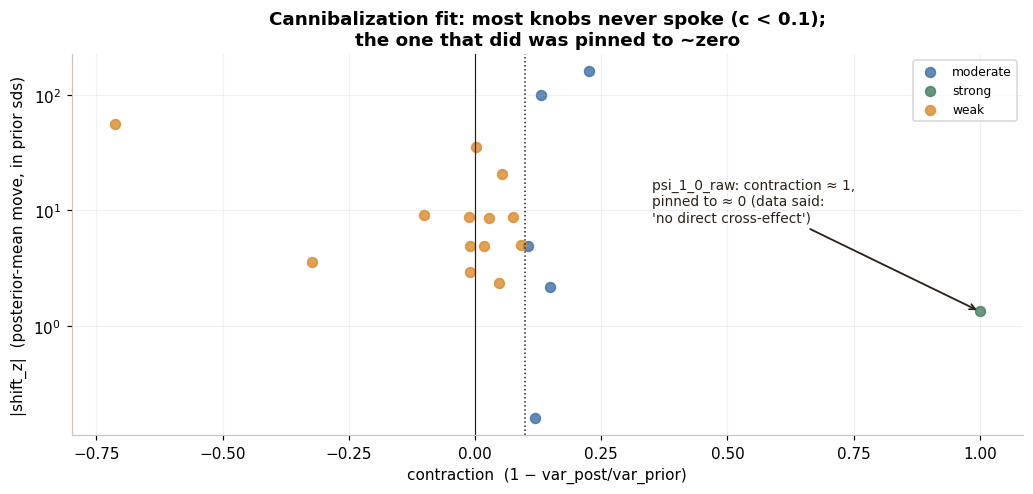

weakly identified (contraction < 0.1): 13/19 (cannibal. fit), 16/19 (unconstrained fit)
✓ the majority of the multivariate model's free parameters sit at c < 0.1


In [18]:
# Contraction vs what-the-data-said: informativeness is NOT importance.
# x = contraction (did the data speak?), y = |shift_z| (how far the mean moved,
# in prior sds). The famous case: psi_1_0_raw at contraction ~ 1 pinned to ~0.
fig, ax = plt.subplots(figsize=(9.5, 4.6))
from mmm_framework.diagnostics.learning import _VERDICT_COLORS
for verdict, grp in lrn_can.groupby("verdict"):
    ax.scatter(grp["contraction"], grp["shift_z"].abs(), s=42, alpha=0.8,
               color=_VERDICT_COLORS.get(verdict, MUTED), label=verdict)
ax.set_yscale("symlog", linthresh=1.0)
ax.annotate("psi_1_0_raw: contraction ≈ 1,\npinned to ≈ 0 (data said:\n'no direct cross-effect')",
            xy=(psi_row_can.contraction, abs(psi_row_can.shift_z)),
            xytext=(0.35, 8.0), fontsize=9, color=INK,
            arrowprops=dict(arrowstyle="->", color=INK, lw=1.2))
ax.axvline(0, color=INK, lw=0.8); ax.axvline(0.1, color=INK, ls=":", lw=1)
ax.set_xlabel("contraction  (1 − var_post/var_prior)")
ax.set_ylabel("|shift_z|  (posterior-mean move, in prior sds)")
ax.set_title("Cannibalization fit: most knobs never spoke (c < 0.1);\n"
             "the one that did was pinned to ~zero")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

n_weak_can = int((lrn_can.contraction < 0.1).sum())
n_weak_unc = int((lrn_unc.contraction < 0.1).sum())
print(f"weakly identified (contraction < 0.1): {n_weak_can}/{len(lrn_can)} "
      f"(cannibal. fit), {n_weak_unc}/{len(lrn_unc)} (unconstrained fit)")
assert n_weak_can >= 8 and n_weak_unc >= 8, \
    "most of the MV machinery should be weakly identified on 104 weekly obs"
print("✓ the majority of the multivariate model's free parameters sit at c < 0.1")

> **Act 2 takeaway.** Before believing a new structural parameter, **count the
> moments** it must share with its neighbors: $\psi$ + $\rho$ ask 4 numbers of
> 3, so the split is the prior's choice — demonstrated by the flip (ψ ≈ 0 with
> a solidly positive ρ under one prior; ψ ≫ 0 with ρ near zero under the
> other, *same data*).
> The doctrine, in three clauses: **(1)** a sign-constrained prior turns "the
> data says ψ<0" into "the prior says ψ<0"; **(2)** contraction ≈ 1 means *the
> data spoke within this parameterization* — read the posterior **location**
> to learn what it said (here: "no direct cross-effect"), and remember a second
> parameterization can extract a different confession; **(3)** the co-movement
> that *is* identified — the total residual covariance — lives in ρ when ψ is
> pinned, and that is a symmetric **association**, not a substitution estimate.
> To measure *causal* cannibalization, move something exogenous: cross-price,
> a promo experiment, a share model. (The framework's own `cross_effect`
> docstring says the same — the trap is documented; the flip makes it felt.)

---
# Act 3 — `CombinedMMM`: the compounding bill

The synthesis model is Acts 1 and 2 fused: mediators routing media into
**multiple** outcomes with cross-effects and a multivariate likelihood. Every
identification debt we just itemized comes along — the shared-mediator split
(Act 1), the $\psi/\rho$ split (Act 2) — **plus** their interactions, on the
same 104 weekly observations.

A confession from this notebook's first edition: this act used to demonstrate
the bill with a live crash. The combined model's cross-effect block was then
*less* disciplined than `MultivariateMMM`'s — it declared one free $\psi$ for
**every** ordered outcome pair plus never-used diagonal entries, as
`pm.Normal("psi", dims=("outcome", "outcome"))`, ignoring the configured
arrow's direction and sign constraint. The duplicate dims crashed PyMC's
post-sampling convergence checks *and* the learning diagnostic; the fit only
survived with `compute_convergence_checks=False`, threw divergences by the
hundred, and r-hats sat far above 1 at a budget where both parents converged.

**Those bugs are fixed** — this stress test is why. `CombinedMMM` now builds
its cross-effects through the same machinery as `MultivariateMMM`: one
sign-constrained RV per *configured* direction (here a single
`psi_1_0_raw` for the cannibalization arrow), structural zeros everywhere
else, no diagonal knobs; and `CombinedModelConfigBuilder.add_cross_effect()` /
`CombinedMMM.get_cross_effects_summary()` now mirror the multivariate API.

So the crash is gone. The **identification arithmetic is not** — repairing an
implementation does not mint new data moments, and the $\psi/\rho$ split of
Act 2 rides along unchanged. Fit the repaired model and grade both claims.

In [19]:
from mmm_framework.mmm_extensions.models import CombinedMMM
from mmm_framework.mmm_extensions.builders import CombinedModelConfigBuilder

comb_cfg = (CombinedModelConfigBuilder()
            .add_mediator(MediatorConfigBuilder("awareness")
                          .partially_observed(observation_noise=0.1)
                          .with_positive_media_effect(sigma=1.0)
                          .with_direct_effect(sigma=0.5).build())
            .map_channels_to_mediator("awareness", BRAND)
            .add_outcome(OutcomeConfigBuilder("sales_original", column="sales_original")
                         .with_positive_media_effects(sigma=0.5).build())
            .add_outcome(OutcomeConfigBuilder("sales_coldbrew", column="sales_coldbrew")
                         .with_positive_media_effects(sigma=0.5).build())
            .with_cannibalization("sales_coldbrew", "sales_original")
            .map_mediator_to_outcomes("awareness", ["sales_original", "sales_coldbrew"])
            .build())

comb = CombinedMMM(X, outcomes, list(CHANNELS), comb_cfg,
                   mediator_data={"awareness": aurora.awareness_survey},
                   index=aurora.weeks)
t0 = time.perf_counter()
with quiet():
    # No compute_convergence_checks=False anymore: the duplicate-dims psi that
    # used to crash PyMC's post-sampling checks is gone, so they run -- clean.
    comb.fit(draws=300, tune=300, chains=2, cores=1, random_seed=0)
TIMINGS["CombinedMMM"] = round(time.perf_counter() - t0, 1)
ndiv = int(comb.trace.sample_stats["diverging"].sum())
n_total = comb.trace.posterior.sizes["chain"] * comb.trace.posterior.sizes["draw"]
print(f"CombinedMMM fitted in {TIMINGS['CombinedMMM']}s")
print(f"divergences: {ndiv} of {n_total} post-warmup draws")

scalar_vars = [v for v in comb.trace.posterior.data_vars
               if "mu" not in v and "_latent" not in v and "effect_" not in v]
rhat_c = float(az.rhat(comb.trace.posterior[scalar_vars]).to_array().max())
print(f"max r-hat over structural parameters: {rhat_c:.3f}")

# The cross-effect block the repaired model builds: ONLY the configured arrow.
psi_rvs = sorted(rv.name for rv in comb.model.free_RVs if rv.name.startswith("psi"))
print(f"\nfree psi RVs: {psi_rvs}  (one sign-constrained arrow, as configured —")
print("no reverse direction, no diagonal knobs, no full matrix)")
print("\nconfigured cross-effect posterior (same API as MultivariateMMM now):")
display(comb.get_cross_effects_summary().round(3))

assert "psi" not in {rv.name for rv in comb.model.free_RVs}, \
    "the old full-matrix psi RV must be gone"
assert psi_rvs == ["psi_1_0_raw"], \
    "exactly one psi RV: the configured Cold Brew -> Original arrow"
assert ndiv < 0.02 * n_total, \
    "the repaired combined fit should sample ~cleanly at this budget"
assert rhat_c < 1.1, \
    "the repaired combined fit should converge at its parents' budget"
print(f"\n✓ measured: the fit that used to throw hundreds of divergences with")
print(f"  r-hats near 3 now samples with {ndiv} divergences and max r-hat")
print(f"  {rhat_c:.3f} at the SAME budget — phantom knobs were the pathology.")

Output()

We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


CombinedMMM fitted in 47.1s
divergences: 0 of 600 post-warmup draws
max r-hat over structural parameters: 1.015

free psi RVs: ['psi_1_0_raw']  (one sign-constrained arrow, as configured —
no reverse direction, no diagonal knobs, no full matrix)

configured cross-effect posterior (same API as MultivariateMMM now):


,source,target,effect_type,mean,sd,hdi_3%,hdi_97%
0,sales_coldbrew,sales_original,cannibalization,-1.248,0.029,-1.302,-1.195



✓ measured: the fit that used to throw hundreds of divergences with
  r-hats near 3 now samples with 0 divergences and max r-hat
  1.015 at the SAME budget — phantom knobs were the pathology.


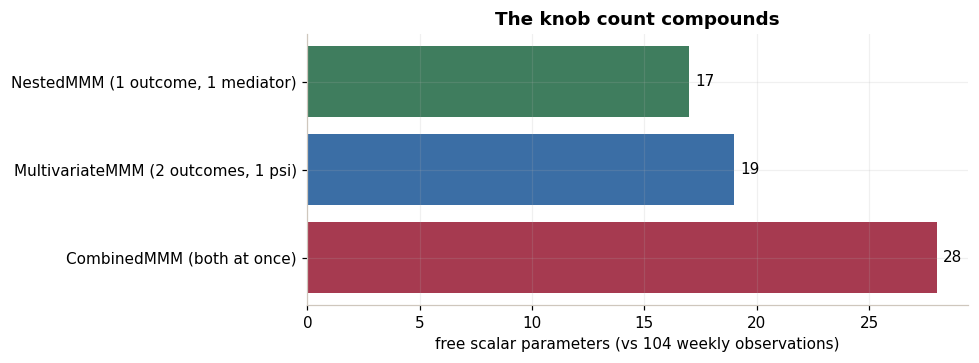

NestedMMM (1 outcome, 1 mediator)      17
MultivariateMMM (2 outcomes, 1 psi)    19
CombinedMMM (both at once)             28

✓ the synthesis carries the largest parameter bill of the three


In [20]:
# The knob bill, itemized: free scalar parameters per model vs the data.
# (The first edition's combined model carried three MORE knobs than this —
# phantom psi entries the config never asked for. The bill below is all real.)
def free_param_count(model):
    n = 0
    for rv in model.free_RVs:
        sh = rv.shape.eval()
        n += int(np.prod(sh)) if len(sh) else 1
    return int(n)

counts = pd.Series({
    "NestedMMM (1 outcome, 1 mediator)": free_param_count(nested.model),
    "MultivariateMMM (2 outcomes, 1 psi)": free_param_count(mv_can.model),
    "CombinedMMM (both at once)": free_param_count(comb.model),
}, name="free scalar parameters")

fig, ax = plt.subplots(figsize=(9, 3.4))
bars = ax.barh(counts.index[::-1], counts.values[::-1], color=[BERRY, SKY, LEAF])
ax.bar_label(bars, padding=4, fontsize=10)
ax.set_xlabel("free scalar parameters (vs 104 weekly observations)")
ax.set_title("The knob count compounds")
plt.tight_layout(); plt.show()
print(counts.to_string())

assert counts["CombinedMMM (both at once)"] > counts.iloc[0] and \
       counts["CombinedMMM (both at once)"] > counts.iloc[1], \
    "the combined model must carry the most knobs"
print("\n✓ the synthesis carries the largest parameter bill of the three")

In [21]:
# And the Act-2 guardrail? In the first edition this call CRASHED on the
# duplicate-dims psi -- the model that needed the prior-vs-posterior audit the
# most was the one that couldn't run it. Now it runs; read what it says.
with quiet():
    lrn_comb = comb.compute_parameter_learning(prior_samples=1000, random_seed=0)
assert isinstance(lrn_comb, pd.DataFrame) and len(lrn_comb) > 0, \
    "the learning audit must run on CombinedMMM now"
n_weak_comb = int((lrn_comb.contraction < 0.1).sum())
print(f"compute_parameter_learning runs: {len(lrn_comb)} parameters audited;")
print(f"weakly identified (contraction < 0.1): {n_weak_comb}/{len(lrn_comb)}")

psi_lrn = lrn_comb[lrn_comb.parameter.str.contains("psi")].set_index("parameter")
display(psi_lrn[["prior_sd", "post_sd", "contraction", "overlap", "shift_z",
                 "verdict"]].round(3))

# What the audit cannot fix is Act 2's arithmetic: ONE configured cross-effect
# still asks four structural parameters (sigma_1, sigma_2, rho, psi) of the
# same three residual moments. Same data, same arrow, same sign-constrained
# prior -- read where each MODEL put the psi/rho split:
spec_c = comb._cross_effect_specs[0]
psi_comb = comb.trace.posterior["psi_matrix"][:, :, spec_c.source_idx,
                                              spec_c.target_idx].values.flatten()
rho_comb = float(comb.trace.posterior["Y_obs_correlation"][:, :, 0, 1].mean())

def pct_of_original(psi_mean):
    return 100 * np.abs(psi_mean * aurora.sales_coldbrew).mean() / aurora.sales_original.mean()

echo = pd.DataFrame({
    "psi mean (CB→Orig)": [psi_can.mean(), psi_comb.mean()],
    "P(psi<0)": [(psi_can < 0).mean(), (psi_comb < 0).mean()],
    "psi effect as % of Original's weekly sales": [
        pct_of_original(psi_can.mean()), pct_of_original(psi_comb.mean())],
    "residual corr rho": [rho_can, rho_comb],
    "psi contraction": [float(psi_row_can.contraction),
                        float(psi_lrn["contraction"].iloc[0])],
}, index=["MultivariateMMM (Act 2)", "CombinedMMM (this act)"]).round(3)
display(echo)

assert (psi_comb < 0).mean() > 0.999, \
    "sign-constrained prior: P(psi<0)~1 by construction, here as in Act 2"
assert psi_comb.mean() < -0.5, \
    "combined: the same arrow now carries a LARGE negative effect..."
assert abs(psi_can.mean()) < 0.01, \
    "...that the multivariate fit, on the same data, pinned to ~zero"
assert float(psi_lrn["contraction"].iloc[0]) > 0.9, \
    "and each model's data 'confidently' pinned psi -- to different answers"
assert n_weak_comb > len(lrn_comb) / 2, \
    "most of the combined model's knobs still never speak"
print("\n✓ measured: same data, same arrow, same prior family — the multivariate")
print("  fit pinned psi ≈ 0 and parked the co-movement in rho; the combined fit")
print("  pins psi to a large negative value. Adding the mediator block changed")
print("  the mean structure, and the unidentified psi/rho split simply landed")
print("  somewhere else. Contraction is ≈1 in both: each parameterization")
print("  extracted a different confession from the same three moments.")

compute_parameter_learning runs: 28 parameters audited;
weakly identified (contraction < 0.1): 17/28


,prior_sd,post_sd,contraction,overlap,shift_z,verdict
parameter,,,,,,
psi_1_0_raw,0.172,0.029,0.972,0.0,5.856,strong


,psi mean (CB→Orig),P(psi<0),psi effect as % of Original's weekly sales,residual corr rho,psi contraction
MultivariateMMM (Act 2),-0.000,1.0,0.013,0.407,1.000
CombinedMMM (this act),-1.248,1.0,54.082,-0.134,0.972



✓ measured: same data, same arrow, same prior family — the multivariate
  fit pinned psi ≈ 0 and parked the co-movement in rho; the combined fit
  pins psi to a large negative value. Adding the mediator block changed
  the mean structure, and the unidentified psi/rho split simply landed
  somewhere else. Contraction is ≈1 in both: each parameterization
  extracted a different confession from the same three moments.


> **Act 3 takeaway.** `CombinedMMM` is the right shape for a real question
> (multi-product brand building) — `math_06` §4 derives its routed
> total-effect decomposition, which is genuinely useful. The implementation
> bugs this stress test surfaced in its first edition — the every-direction
> `psi` matrix with dead diagonal knobs, the divergence storm at the parents'
> budget, the crashed convergence checks and learning audit — **are fixed**:
> the model now spends exactly the knobs the config asks for and samples
> cleanly. What no bugfix can supply is identification. The bill that remains
> is the **sum** of Acts 1 and 2 plus interactions: the shared-mediator split
> rides along from Act 1, and the configured cross-effect still asks the
> likelihood to split outcome co-movement between $\psi$ and $\rho$ — four
> parameters against three moments. Measured above: the *same* arrow, on the
> *same* data, under the *same* prior family, lands at $\psi \approx 0$ in
> one model and a large negative $\psi$ in the other, each with contraction
> ≈ 1 — structure, not data, chose. If you reach for it, bring **per-path
> external evidence** (a mediator experiment, a cross-price study) — or
> report every cross-effect as a labeled prior assumption, now at least a
> cleanly-sampled one.

---
# The extension decision rule

Everything this notebook measured compresses into one workflow:

1. **Reach for an extension when the DAG says the base *estimand* is wrong** —
   not when you want a richer story. Mediation was a real case: the decision
   question needs the *total* effect, and the base model structurally reported
   something else (and here, couldn't even see it). "Our products feel coupled"
   was not a real case: the coupling the data identifies (total residual
   covariance) was already representable; the extension only *named* an
   un-identified split.
2. **Price every new latent path before fitting.** Each one must be *(i)*
   identified by countable data moments (count them: $\psi$+$\rho$ = 4 asks of
   3), *(ii)* pinned by external evidence (the awareness **survey** is why
   rung (c) worked; `add_experiment_calibration` is the general mechanism), or
   *(iii)* honestly labeled a prior assumption in the deliverable. There is no
   fourth category — "the sampler converged" is not identification.
3. **Always run `compute_parameter_learning` on the new parameters** — and read
   it as *informativeness, not importance*. Contraction ≈ 1 pinned to ≈ 0 means
   "the data confidently says this knob does nothing" *within that
   parameterization* (Act 2's $\psi$ — which Act 3's combined model, same arrow
   and prior, just as confidently pinned to a large negative value);
   contraction < 0 means prior–data tension (our $\beta$ edges — in the
   *correct* model too); c ≈ 0 with high overlap means the posterior is the
   prior wearing a lab coat.
4. **Sign-constrained priors convert "the data says" into "the prior says".**
   $\mathbb{P}(\psi<0)\approx 1$ under $\psi=-\mathrm{HalfNormal}$ is a
   tautology. Fit the signless version as a sensitivity: if the story flips
   (ours reversed completely), the direction was never yours to report.

## What to remember

- **An extension fixes an estimand; it does not create information.** Rung (c)
  worked because the survey was *new likelihood*, not because the model grew
  more structure. Structure without new information = priors with better
  marketing.
- **The unidentifiable part doesn't disappear — it relocates.** TV's flat
  exposure broke the base model; inside `NestedMMM` it broke the TV/Display
  *split* instead, one level down where nobody audits, and over-credited
  Display with an interval that excludes the truth.
- **The model cannot audit its own arrows.** The wrong-mediator fit was as
  clean, as confident, and as plausible as the right one. Mediator validity,
  cross-effect direction, mediator→outcome routing: all assumptions, all
  payable only in external evidence.
- **Confidence under a one-sided prior is the cheapest commodity in Bayes.**
  Audit it with contraction/overlap, then audit the *parameterization* with a
  prior flip.
- **A bugfix is not identification.** The combined model's divergence storm
  and crashed audits — found by this stress test's first edition — are fixed,
  and the fits above sample cleanly. The $\psi/\rho$ split they sample so
  cleanly is exactly as prior-and-structure-determined as before; smoother
  sampling only makes the assumption easier to mistake for a finding.

**Next — `stress_05_the_gauntlet`:** the capstone. Everything the series broke,
in one realistic workflow — symptom → cause → pivot table included.

In [22]:
# Wall-clock accounting for every fit in this notebook.
budget = pd.Series(TIMINGS, name="seconds")
display(budget.to_frame())
print(f"total fitting time: {budget.sum():.0f}s across {len(budget)} fits "
      "(cores=1 sequential chains — macOS requirement for the extension models)")

,seconds
"(a) base, no awareness",20.5
(b) base + awareness control,17.4
(c) NestedMMM,18.7
(d) NestedMMM wrong mediator,18.2
MV cannibalization prior,18.0
MV unconstrained prior,14.4
CombinedMMM,47.1


total fitting time: 154s across 7 fits (cores=1 sequential chains — macOS requirement for the extension models)
